-----------------------------

-----------------------------

## **<u>LIBRARIES</u>:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

-----------------------------

-----------------------------

## **<U>LOADING</U> <U>DATASET</U>:**

In [2]:
df = pd.read_csv("Practo_DataSets.csv")

-----------------------------

-----------------------------

## **<U>UNDERSTANDING</U> <U>DATASET</U>:**

In [3]:
df.head()

,Doctor_Name,Specialization,Experience,Hospital_Name,City,City_Tier,Patient_Rating(%),Source,Consultation_Fee(₹)
0,Dr. Anil Krishna Gundala,Cardiologist,23,Medicover Hospitals,Hyderabad,Metro,96.0,Practo,800
1,Dr. Sai Ravi Shanker A,Cardiologist,31,Aster Prime Hospital,Hyderabad,Metro,60.0,Practo,800
2,Dr. R. Balaji,Cardiologist,37,Medicover Hospitals,Hyderabad,Metro,97.0,Practo,900
3,Dr. Krishna Prasad A R,Cardiologist,32,Medicover Hospitals,Hyderabad,Metro,82.0,Practo,800
4,Dr. Shiva Prasad Koyalakonda,Cardiologist,23,One Cardiac Centre,Hyderabad,Metro,93.0,Practo,700


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Doctor_Name          1080 non-null   object 
 1   Specialization       1080 non-null   object 
 2   Experience           1080 non-null   int64  
 3   Hospital_Name        1080 non-null   object 
 4   City                 1080 non-null   object 
 5   City_Tier            1080 non-null   object 
 6   Patient_Rating(%)    1080 non-null   float64
 7   Source               1080 non-null   object 
 8   Consultation_Fee(₹)  1080 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 76.1+ KB


In [5]:
df.columns

Index(['Doctor_Name', 'Specialization', 'Experience', 'Hospital_Name', 'City',
       'City_Tier', 'Patient_Rating(%)', 'Source', 'Consultation_Fee(₹)'],
      dtype='object')

In [6]:
df["Specialization"].unique()

array(['Cardiologist', 'Dentist', 'Dermatologist', 'ENT',
       'General Physician', 'General Surgeon', 'Gynecologist',
       'Neurologist', 'Orthopedist'], dtype=object)

In [7]:
df["City"].unique()

array(['Hyderabad', 'Kolkata', 'Chennai', 'Delhi', 'Bangalore', 'Mumbai',
       'Ahmedabad', 'Chandigarh', 'Patna', 'Lucknow', 'Pune',
       'Visakhapatnam'], dtype=object)

-----------------------------

-------------

**<h1 align="center"><u>PHASE-01</u>: DISCRIPTIVE MARKET OVERVIEW</h1>**

### **POINT OF DISCUSSION & ANALYSIS:**
1. **`OVERALL FEE LANDSCAPE`**
2. **`City-wise Pricing Analysis`**
3. **`Specialization-wise Pricing Analysis`**

### ***1. `OVERALL FEE LANDSCAPE`:***

In [8]:
fee_stats = df["Consultation_Fee(₹)"].agg({
    "Average Fee": "mean",
    "Median Fee": "median",
    "Minimum Fee": "min",
    "Maximum Fee": "max",
    "Std Deviation": "std",
    "Total Doctors": "count"
}).round(2)

fee_stats

Average Fee       829.35
Median Fee        800.00
Minimum Fee         0.00
Maximum Fee      4000.00
Std Deviation     434.86
Total Doctors    1080.00
Name: Consultation_Fee(₹), dtype: float64

***A) Creating a histogram to visualize the distribution of consultation fees:***

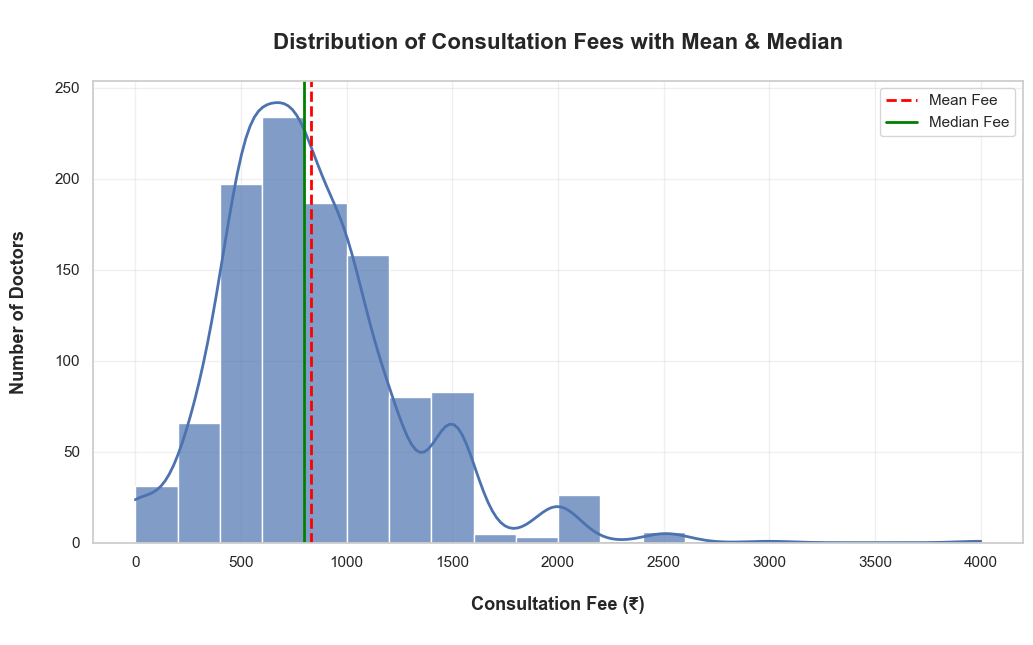

In [9]:
sns.set_theme(style="whitegrid") # "whitegrid" adds a white background with light grid lines
plt.figure(figsize=(12,6))

sns.histplot(
    df["Consultation_Fee(₹)"],
    bins=20,
    kde=True, # Enable KDE (Kernel Density Estimation) to show the smooth distribution curve
    color="#4C72B0", # Color of the histogram bars: Dark moderate brown
    alpha=0.7, # Adjust transparency of bars
    line_kws={"linewidth":2, "color":"darkblue"}  # Customize the KDE line
)


# Adding a vertical line showing the mean (average) consultation fee
plt.axvline(
    df["Consultation_Fee(₹)"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mean Fee'
)


# Adding a vertical line showing the median consultation fee
plt.axvline(
    df["Consultation_Fee(₹)"].median(),
    color='green',
    linestyle='-',
    linewidth=2,
    label='Median Fee'
)

plt.title("\nDistribution of Consultation Fees with Mean & Median\n", fontsize=16, fontweight="bold")
plt.xlabel("\nConsultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.ylabel("Number of Doctors\n", fontsize=13, fontweight="bold")

plt.legend() # Display the legend explaining the mean and median lines
plt.grid(alpha=0.3) # Add light grid lines for better readability
plt.show()

- *What this `histogram` will show to us?*

```text
Through this histogram, we will see:

- Whether most doctors charge ₹500–₹1000
- Whether some doctors charge premium fees

This helps detect skewness.
```

- *Insights from `histogram` Plot:*

```text
 1. Most doctors charge consultation fees roughly between ₹500 and ₹1000,
    indicating that the urban healthcare market largely operates within a mid-range pricing segment.
 2. The distribution has a long right tail, with some doctors charging ₹2000–₹4000,
    indicating the presence of a small premium segment that drives higher-end healthcare pricing.
 3. The mean fee is slightly higher than the median,
    suggesting that a relatively small number of high-fee doctors are pulling the overall average upward,
    reinforcing the existence of premium-priced providers.
```

***B) Studying the effects of <U>OUTLIERS</U> on Consultancy Fee:***

- ***Our Working Dataframes:***
```text
- Raw/Unfiltered/Original Dataset -----------> `df`
- Filtered Dataset (Without Outliers) -------> `df_no_outliers`
```

- ***Average Consultation Fee:***
```text
- Original Dataset ---> `avg_fee_all`
- Filtered Dataset ---> `avg_fee_clean`
```

**`IQR METHOD` (Outlier Detection):**
- This method finds extremely low or extremely high consultation fees.

In [10]:
    Q1 = df["Consultation_Fee(₹)"].quantile(0.25)
    Q3 = df["Consultation_Fee(₹)"].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    lower_bound, upper_bound

(np.float64(-250.0), np.float64(1750.0))

```python
Lower Bound = -250 INR
Upper Bound = 1750 INR
```

```text
Meaning: Doctors charging above ₹1750 are outliers.
```

- Removing Outlier by filtering DataSet:

In [11]:
    df_no_outliers = df[
        (df["Consultation_Fee(₹)"] >= lower_bound) &
        (df["Consultation_Fee(₹)"] <= upper_bound)
    ]


- Number of Doctors in Raw Dataset and Filtered(Outlier Free) Dataset Comparison:

In [12]:
    print(f"Total Number of Doctors in Raw Datasets:- {df.shape[0]}")
    print(f"Total Number of Doctors in Filtered Datasets:- {df_no_outliers.shape[0]}") # Filterd Doctors
    
    print(f"\nSo, \n  Total Number Of Outliers Found: {df.shape[0] - df_no_outliers.shape[0]}\n")

Total Number of Doctors in Raw Datasets:- 1080
Total Number of Doctors in Filtered Datasets:- 1041

So, 
  Total Number Of Outliers Found: 39



- Average Consultancy fee Comparison `Raw DataSet` vs `Filtered DataSet`:

In [13]:
    # Average Consultancy Fee Of Raw DataSet:

    avg_fee_all = df["Consultation_Fee(₹)"].mean()
    print(f"\nAverage Consultancy Fee Of Raw DataSet:- ₹{avg_fee_all:.2f}\n")  # .2f --> Shows decimal upto 2 value


Average Consultancy Fee Of Raw DataSet:- ₹829.35



In [14]:
# Average Consultancy Fee of Filtered DataSet:

avg_fee_clean = df_no_outliers["Consultation_Fee(₹)"].mean()
print(f"\nAverage Consultancy Fee of Filtered DataSet:- ₹{avg_fee_clean:.2f}\n")


Average Consultancy Fee of Filtered DataSet:- ₹779.54



In [15]:
# Avg (Mean) Comparison between Raw and Filtered DataSet

comparison = pd.DataFrame({
    "Scenario": ["Raw DataSet (Including Outliers)", "Filtered DataSet (Excluding Outliers)"],
    "Avg_Consultation_Fee": [avg_fee_all, avg_fee_clean]
})

comparison.style.format({"Avg_Consultation_Fee": "₹{:.2f}"})

,Scenario,Avg_Consultation_Fee
0,Raw DataSet (Including Outliers),₹829.35
1,Filtered DataSet (Excluding Outliers),₹779.54


- Median Fee Value Comparison `Raw DataSet` vs `Filtered DataSet`:

In [16]:
comparison_median = pd.DataFrame({
    "Scenario": ["Raw DataSet (Including Outliers)", "Filtered DataSet (Excluding Outliers)"],
    "Median_Fee_Value": [df["Consultation_Fee(₹)"].median(), df_no_outliers["Consultation_Fee(₹)"].median()]
})

comparison_median.style.format({"Median_Fee_Value": "₹{:.2f}"})

,Scenario,Median_Fee_Value
0,Raw DataSet (Including Outliers),₹800.00
1,Filtered DataSet (Excluding Outliers),₹750.00


**<u>VISUALISATION</u> <u>USING</u> <u>BOXPLOT</u>:**

***1. `With Outliers`***

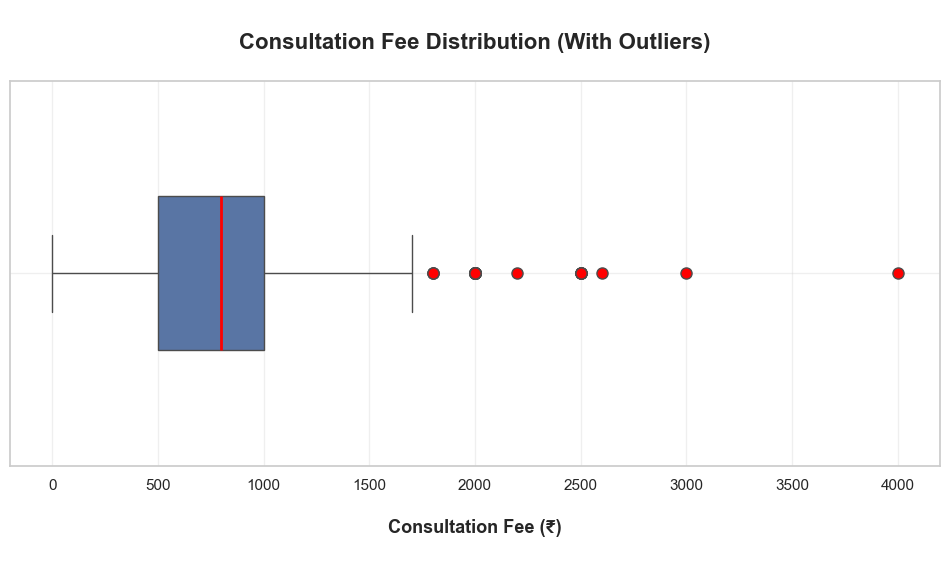

In [17]:
sns.set_theme(style="whitegrid")  # Whitegrid background theme

plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["Consultation_Fee(₹)"],
    color="#4C72B0", # color of the box --> Dark moderate blue
    width=0.4, 
    medianprops={"color":"red","linewidth":2}, # Customize the median line inside the box
    flierprops=dict(marker='o', markerfacecolor='red', markersize=8) # Customize the appearance of outliers
)

plt.title("\nConsultation Fee Distribution (With Outliers)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nConsultation Fee (₹)\n", fontsize=13, fontweight="bold")

plt.grid(alpha=0.3) # Added grid lines with light transparency
plt.show()

Key Insights:
```text
 1. Majority of Consultation Fees Lie in the Mid-Range (₹500–₹1000)
 2. Presence of High-Priced Outliers Indicates a Premium Healthcare Segment
 3. Large Fee Spread Suggests Significant Pricing Variability Among Doctors
```

- Raw DataSet:- Mean(avg) and Median:

In [18]:
# Raw Dataset --> Mean (vs) Median

avg_fee_all = df["Consultation_Fee(₹)"].mean()
median_fee_all = df["Consultation_Fee(₹)"].median()

print(f"\nMean value (with outlier): {avg_fee_all:.2f}")
print(f"Median value (with outlier):{median_fee_all}\n")
print("So in the first boxplot, the median shows:\n- The typical consultation fee even when extreme values exist.\n")


Mean value (with outlier): 829.35
Median value (with outlier):800.0

So in the first boxplot, the median shows:
- The typical consultation fee even when extreme values exist.



***2. `Without Outliers`***

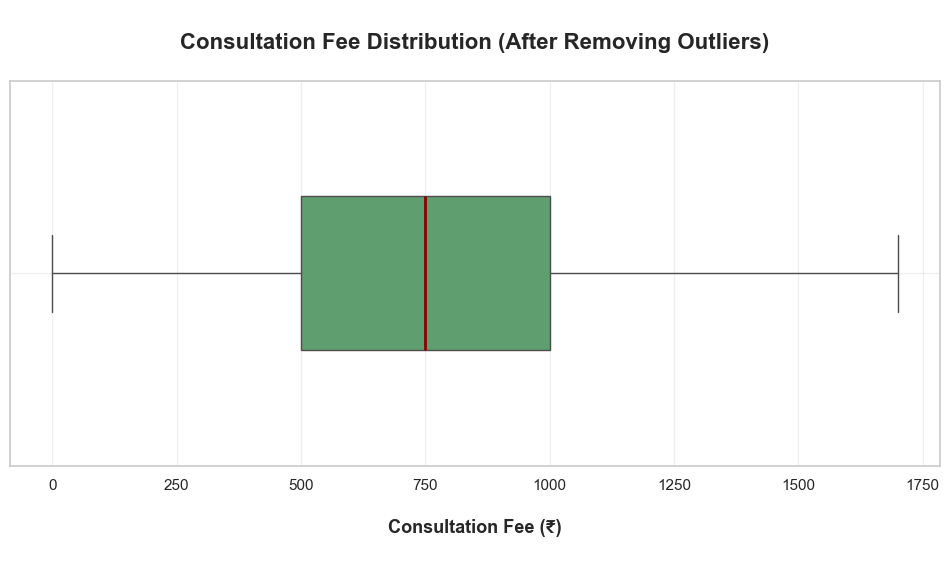

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,5))


# Create a boxplot for the consultation fees after removing outliers
sns.boxplot(  
    x=df_no_outliers["Consultation_Fee(₹)"],  # Used the cleaned dataset where outliers have been removed
    color="#55A868", # Box color --> Greenish
    width=0.4,
    medianprops={"color":"darkred", "linewidth":2}
)

plt.title("\nConsultation Fee Distribution (After Removing Outliers)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nConsultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()


```text
What the Median Shows Here?
Now the median represents:
- The middle consultation fee among doctors within the normal fee range.

Because extreme values are removed:
- The distribution becomes tighter
- The box becomes smaller
- The median represents the realistic market fee
```

- Filtered DataSet:- Mean(avg) and Median:

In [20]:
# Filtered Dataset --> Mean (vs) Median

avg_fee_clean = df_no_outliers["Consultation_Fee(₹)"].mean()
median_fee_clean = df_no_outliers["Consultation_Fee(₹)"].median()

print(f"\nMean value (without outlier): {avg_fee_clean:.2f}")
print(f"Median value (without outlier):{median_fee_clean}\n")
print("Now both mean and median are close, showing a stable distribution.\n")


Mean value (without outlier): 779.54
Median value (without outlier):750.0

Now both mean and median are close, showing a stable distribution.



*Why Median Changed from 800 ---> 750?*

```text
Reason,
    we have removed outliers, which means:
    - Some observations were removed from the dataset
    - The total number of rows changed
    - The middle position shifted
```

**<h1 align="center">COMPLETE INSIGHTS OF <u>FEE</u> <U>LANDSCAPE</U></h1>**

***<u>Insight-01</u> — Market Average***
```text
The overall average consultation fee across all doctors(Raw DataSet --> 1080 Doctors) is approximately ₹829, representing the general pricing level in urban healthcare markets.
```

***<u>Insight-02</u> — Presence of Premium Doctors***
```text
The dataset contains extreme consultation fees reaching up to ₹4000, indicating the presence of premium healthcare providers.
```

***<u>Insight-03</u> — Effect of Outliers***
```text
After removing pricing outliers using the IQR method, the average consultation fee decreases to approximately ₹780, suggesting that a small number of high-priced doctors significantly influence the overall market average.
```

***<u>Insight-04</u> — Typical Consultation Range***
```text
The filtered dataset i.e. without outlier dataset better represents the typical consultation fee range that most patients encounter in urban healthcare markets.
```

### ***2. `CITY-WISE PRICING ANALYSIS`:***

**A) Computing Average, Median, Standard Deviation, Min, Max, Doctor Count (Filtered Dataset).**

In [21]:
city_fee_stats = df_no_outliers.groupby("City")["Consultation_Fee(₹)"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Std_Deviation="std",
    Min_Fee="min",
    Max_Fee="max",
    Doctors="count"
).round(2)

city_fee_stats.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors
City,,,,,,
Mumbai,1172.58,1200.0,381.18,500,1600,62
Delhi,1012.64,1000.0,320.18,300,1700,87
Kolkata,967.24,900.0,332.35,300,1600,87
Pune,866.83,800.0,337.81,0,1500,89
Bangalore,852.22,800.0,297.36,300,1500,90
Ahmedabad,806.74,800.0,377.05,0,1600,89
Chennai,716.67,750.0,284.92,0,1500,90
Hyderabad,705.00,700.0,222.61,0,1500,90
Chandigarh,674.14,700.0,301.34,0,1500,87


In [22]:
len(df_no_outliers)

1041

- Finding Expensive and Affrodable City:

In [23]:
most_expensive_city = city_fee_stats["Average_Fee"].idxmax()
most_affordable_city = city_fee_stats["Average_Fee"].idxmin()

print(f"\nMost Expensive City: {most_expensive_city}")
print(f"Most Affordable City: {most_affordable_city}\n")


Most Expensive City: Mumbai
Most Affordable City: Patna



- Average Consunltation Fee by City --> **Visualization by Bar Chart**

C:\Users\ahmad\AppData\Local\Temp\ipykernel_40268\3827771714.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


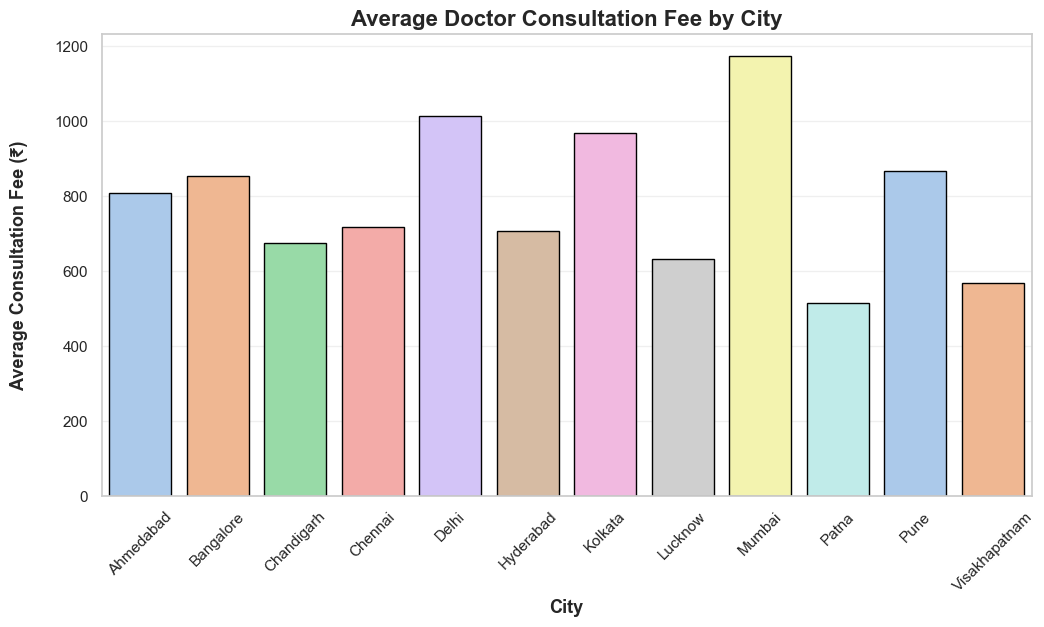

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))


# Creating a bar plot to compare average consultation fees across cities
sns.barplot(
    x=city_fee_stats.index,
    y=city_fee_stats["Average_Fee"],
    palette= "pastel", # viridis/flare/pastel
    edgecolor="black"
)

plt.title("Average Doctor Consultation Fee by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13, fontweight="bold")
plt.ylabel("Average Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45) # Rotate city name to prevent overlapping
plt.grid(axis='y', alpha=0.3) # Added light grid lines to improve readability of values
plt.show()

- Consultation Fee Distribution/spread Across Cities --> **Visualization by Box-Plot**

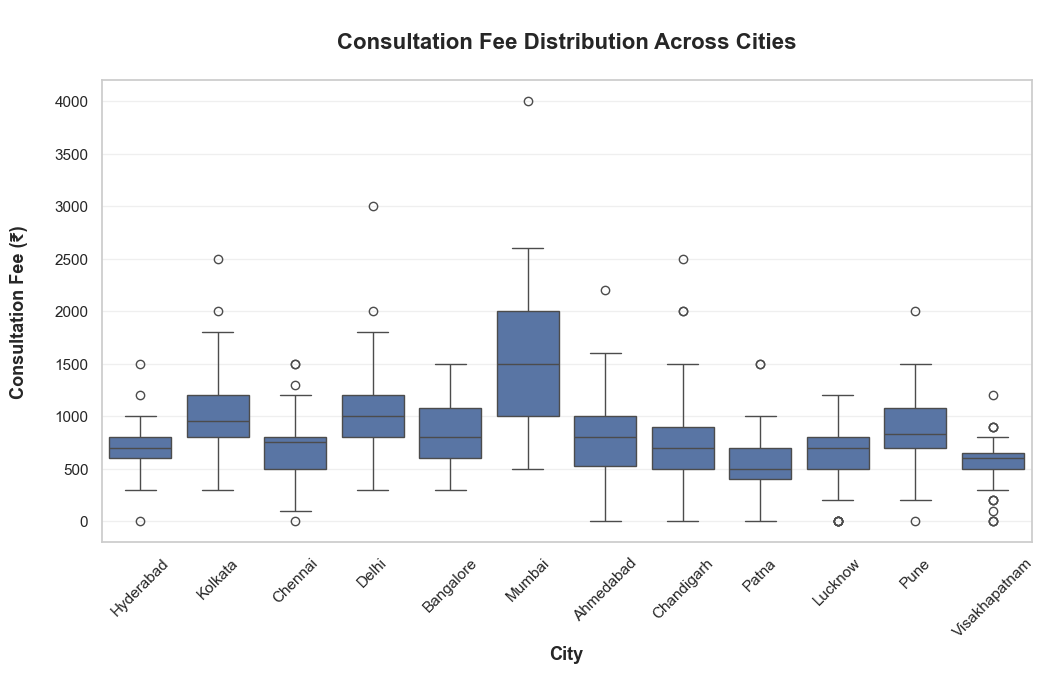

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="City",
    y="Consultation_Fee(₹)"
)

plt.title("\nConsultation Fee Distribution Across Cities\n", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13, fontweight="bold")
plt.ylabel("Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

`Metro vs Non-Metro Analysis`:

In [26]:
tier_fee = df_no_outliers.groupby("City_Tier")["Consultation_Fee(₹)"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Doctors="count"
).round(2)

tier_fee

,Average_Fee,Median_Fee,Doctors
City_Tier,,,
Metro,888.54,800.0,506
Non-Metro,676.44,700.0,535


- Creating a **Bar-Chart** to compare consultation fees between Metro and Non-Metro cities:

C:\Users\ahmad\AppData\Local\Temp\ipykernel_40268\373464620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


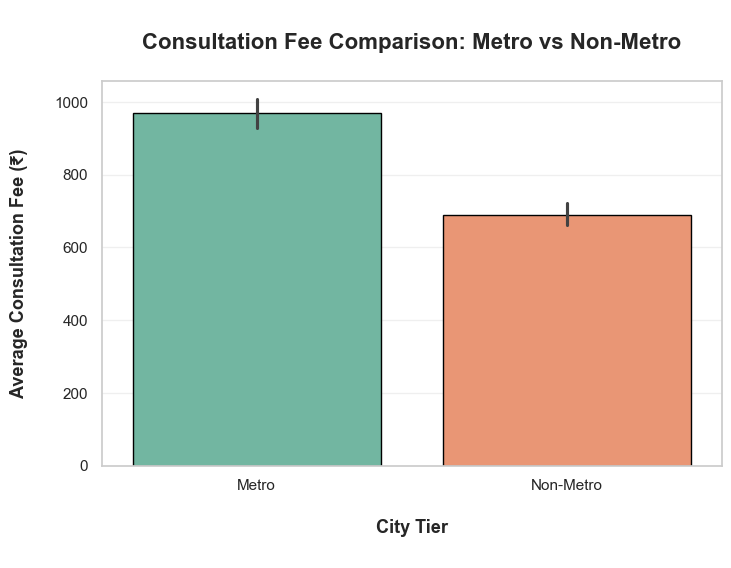

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="City_Tier",
    y="Consultation_Fee(₹)",
    data=df,
    palette="Set2",
    edgecolor="black"
)

plt.title("\nConsultation Fee Comparison: Metro vs Non-Metro\n", fontsize=16, fontweight="bold")
plt.xlabel("\nCity Tier\n", fontsize=13, fontweight="bold")
plt.ylabel("Average Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(axis='y', alpha=0.3) # Added light horizontal grid lines to help compare bar heights
plt.show()


**<h1 align="center">COMPLETE INSIGHTS OF <u>CITY-WISE</u> <u>PRICING</u> <U>ANALYSIS</U></h1>**

***<u>Insight-01</u> — City Pricing Variation***

```text
Consultation fees vary significantly across cities, indicating differences in healthcare market pricing across urban regions.
```

***<u>Insight-02</u> — Most Expensive City***

```text
Among all analyzed cities, Mumbai exhibits the highest average consultation fee, suggesting a premium healthcare market.
```

***<u>Insight-03</u> — Most Affordable City***

```text
Patna has the lowest average consultation fee, indicating relatively more affordable healthcare access.
```

***<u>Insight-04</u> — Pricing Spread***

```text
The boxplot analysis shows that some cities have wider consultation fee distributions (e.g. Mumbai), indicating the presence of both budget and premium healthcare providers.
```

***<u>Insight-05</u> — Metro Premium Effect***

```text
Metro cities demonstrate a higher average consultation fee compared to non-metro cities, indicating a possible urban premium effect in healthcare pricing.
```

### ***3. `SPECIALIZATION-WISE PRICING STATISTICS`***

**A) Calculate Average Fee, Median Fee, Standard Deviation, Min, Max, Doctor Count.**

- Raw DataSets:

In [28]:
spec_fee_stats = df.groupby("Specialization")["Consultation_Fee(₹)"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Std_Deviation="std",
    Min_Fee="min",
    Max_Fee="max",
    Doctors="count"
).round(2)

spec_fee_stats.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors
Specialization,,,,,,
Cardiologist,1016.25,975.0,443.68,0,2500,120
Neurologist,991.25,1000.0,487.91,0,2500,120
General Surgeon,866.67,800.0,497.66,0,4000,120
Orthopedist,859.58,700.0,447.74,0,2600,120
General Physician,858.75,800.0,395.76,0,2500,120
Dermatologist,839.58,800.0,333.80,0,2000,120
ENT,814.17,800.0,415.26,0,3000,120
Gynecologist,792.50,700.0,342.24,0,2000,120
Dentist,425.40,400.0,207.04,0,1500,120


- Filtered DataSet

In [29]:
spec_fee_stats_filt = df_no_outliers.groupby("Specialization")["Consultation_Fee(₹)"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Std_Deviation="std",
    Min_Fee="min",
    Max_Fee="max",
    Doctors="count"
).round(2)

spec_fee_stats_filt.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors
Specialization,,,,,,
Cardiologist,935.27,900.0,329.46,0,1500,112
Neurologist,904.05,900.0,387.72,0,1600,111
Dermatologist,829.83,800.0,317.59,0,1700,119
General Physician,804.78,800.0,302.04,0,1500,115
General Surgeon,800.00,800.0,350.50,0,1600,115
Gynecologist,782.35,700.0,325.05,0,1500,119
Orthopedist,779.20,700.0,312.02,0,1600,113
ENT,776.92,750.0,337.37,0,1500,117
Dentist,425.40,400.0,207.04,0,1500,120


- Sorting Raw DataSet:

In [30]:
spec_fee_stats_sorted = spec_fee_stats.sort_values(
    by="Average_Fee", ascending=False
)

spec_fee_stats_sorted

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors
Specialization,,,,,,
Cardiologist,1016.25,975.0,443.68,0,2500,120
Neurologist,991.25,1000.0,487.91,0,2500,120
General Surgeon,866.67,800.0,497.66,0,4000,120
Orthopedist,859.58,700.0,447.74,0,2600,120
General Physician,858.75,800.0,395.76,0,2500,120
Dermatologist,839.58,800.0,333.80,0,2000,120
ENT,814.17,800.0,415.26,0,3000,120
Gynecologist,792.50,700.0,342.24,0,2000,120
Dentist,425.40,400.0,207.04,0,1500,120


- FEE-SPREAD: **Variance and Standard Variation**
  - <u>Case-01</u>: Including Free Consultation Fee (₹0)
  - <u>Case-02</u>: Excluding Free Consultation Fee (Paid)

In [31]:
# Case-01: Including Free consultation Fee of Doctors

spec_fee_stats["Variance"] = df.groupby("Specialization")["Consultation_Fee(₹)"].var().round(2)
spec_fee_stats.sort_values(by="Variance", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors,Variance
Specialization,,,,,,,
General Surgeon,866.67,800.0,497.66,0,4000,120,247661.06
Neurologist,991.25,1000.0,487.91,0,2500,120,238053.05
Orthopedist,859.58,700.0,447.74,0,2600,120,200474.61
Cardiologist,1016.25,975.0,443.68,0,2500,120,196855.57
ENT,814.17,800.0,415.26,0,3000,120,172444.68
General Physician,858.75,800.0,395.76,0,2500,120,156624.47
Gynecologist,792.50,700.0,342.24,0,2000,120,117128.15
Dermatologist,839.58,800.0,333.80,0,2000,120,111424.19
Dentist,425.40,400.0,207.04,0,1500,120,42864.56


In [32]:
#Case-02: Without free consultance doctors

df_paid = df[df["Consultation_Fee(₹)"] > 0]
spec_fee_stats_paid = df_paid.groupby("Specialization")["Consultation_Fee(₹)"].agg(
    Average_Fee = "mean",
    Median_Fee = "median",
    Std_Deviation = "std",
    Min_Fee = "min",
    Max_Fee = "max",
    Doctors = "count"
).round(2)

spec_fee_stats_paid["Variance"] = df_paid.groupby("Specialization")["Consultation_Fee(₹)"].var().round(2)

spec_fee_stats_paid.sort_values(by="Variance", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors,Variance
Specialization,,,,,,,
General Surgeon,896.55,800.0,478.80,200,4000,116,229248.88
Orthopedist,866.81,700.0,442.56,300,2600,119,195859.21
Neurologist,1052.65,1000.0,433.26,300,2500,113,187716.10
Cardiologist,1042.31,1000.0,417.79,300,2500,117,174552.39
ENT,827.97,800.0,404.81,200,3000,118,163869.33
General Physician,865.97,800.0,389.42,200,2500,119,151649.69
Dermatologist,853.81,800.0,317.92,300,2000,118,101075.08
Gynecologist,819.83,700.0,314.01,300,2000,116,98603.45
Dentist,436.31,400.0,197.92,100,1500,117,39172.99


In [33]:
#Case-02: Excluding Free Consultation Fee (Filtered DataSet)

df_paid_no_outliers = df_no_outliers[df_no_outliers["Consultation_Fee(₹)"] > 0]
spec_fee_stats_paid_no_outliers = df_paid_no_outliers.groupby("Specialization")["Consultation_Fee(₹)"].agg(
    Average_Fee = "mean",
    Median_Fee = "median",
    Std_Deviation = "std",
    Min_Fee = "min",
    Max_Fee = "max",
    Doctors = "count"
).round(2)

spec_fee_stats_paid_no_outliers["Variance"] = df_paid_no_outliers.groupby("Specialization")["Consultation_Fee(₹)"].var().round(2)

spec_fee_stats_paid_no_outliers.sort_values(by="Variance", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors,Variance
Specialization,,,,,,,
ENT,790.43,800.0,324.10,200,1500,115,105039.28
General Surgeon,828.83,800.0,321.26,200,1600,111,103206.80
Neurologist,964.90,1000.0,318.21,300,1600,104,101256.30
Orthopedist,786.16,700.0,304.49,300,1600,112,92712.15
Dermatologist,844.02,800.0,300.87,300,1700,117,90524.24
Gynecologist,809.57,700.0,295.20,300,1500,115,87144.55
Cardiologist,961.01,900.0,294.26,300,1500,109,86590.64
General Physician,811.84,800.0,293.69,200,1500,114,86252.33
Dentist,436.31,400.0,197.92,100,1500,117,39172.99


In both the cases, <br>
- Neurologists and cardiologists show the highest fee variability, indicating the presence of both budget and premium specialists in the market.<br>
  This suggests a segmented market with a mix of junior doctors, experienced specialists, and premium hospital practitioners. <br>
- Dentists exhibit the lowest variance, indicates that consultation fees are relatively consistent across doctors, suggesting standardized pricing <br>
  and higher competitive pressure.

- Side by side comparison: Average Fee by Specialization
  - With free consultancy fee ------> `Avg_Fee_Including_Free`
  - Without free consultancy fee --> `Avg_Fee_Paid_Only`

In [34]:
# Side by side comparison:

comparison = pd.concat(
    [
        spec_fee_stats_filt["Average_Fee"].rename("Avg_Fee_Including_Free"),
        spec_fee_stats_paid_no_outliers["Average_Fee"].rename("Avg_Fee_Paid_Only")
    ],
    axis=1
)

comparison

,Avg_Fee_Including_Free,Avg_Fee_Paid_Only
Specialization,,
Cardiologist,935.27,961.01
Dentist,425.40,436.31
Dermatologist,829.83,844.02
ENT,776.92,790.43
General Physician,804.78,811.84
General Surgeon,800.00,828.83
Gynecologist,782.35,809.57
Neurologist,904.05,964.90
Orthopedist,779.20,786.16


- Comparison Through **Visualisation**

<Figure size 1000x600 with 0 Axes>

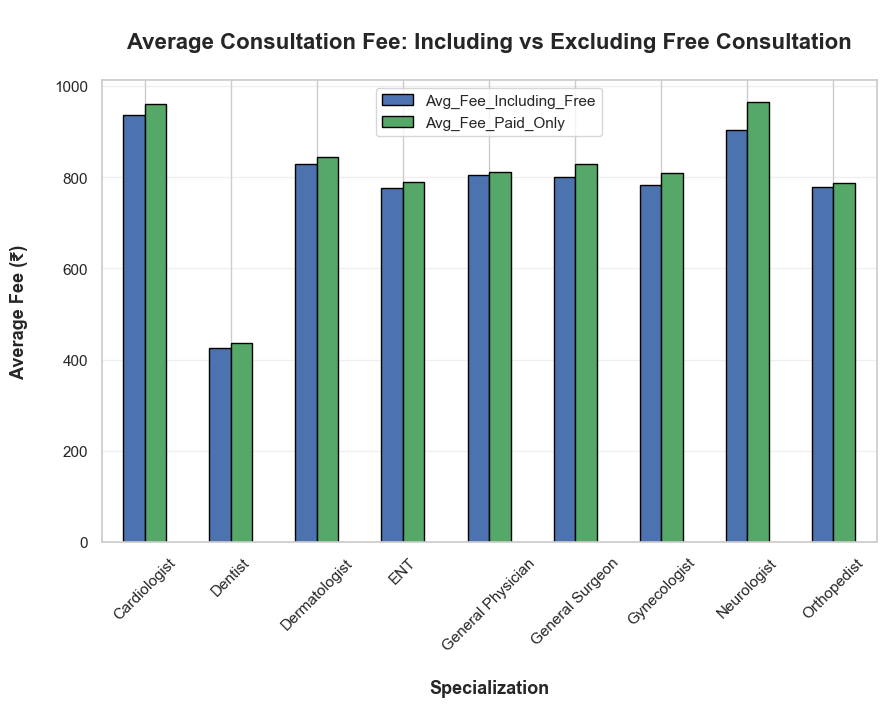

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))


# Plot a bar chart from the 'comparison' DataFrame
# Each bar represents average consultation fee for different scenarios
ax = comparison.plot(
    kind="bar",
    color=["#4C72B0", "#55A868"], # bar colors
    edgecolor="black",
    figsize=(10,6)
)

plt.title(
    "\nAverage Consultation Fee: Including vs Excluding Free Consultation\n",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("Average Fee (₹)\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

- Understanding the Fee-Spread/Distribution of of Consultation Fee across specializations through **Box-Plot**. 

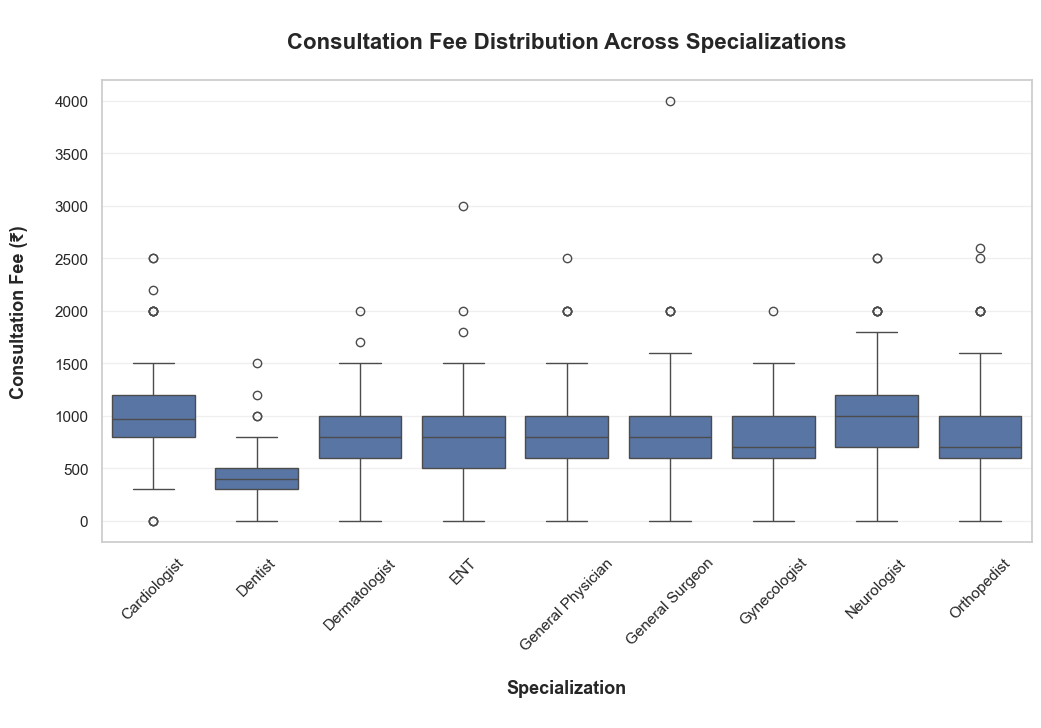

In [36]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Specialization",
    y="Consultation_Fee(₹)"
)

plt.title("\nConsultation Fee Distribution Across Specializations\n",
          fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

```text
This reveals:
- specializations with premium doctors
- specializations with stable pricing
```

**B) Identify Premium vs Budget Specializations:**

In [37]:
# With free consultance fee

premium_specialization = spec_fee_stats["Average_Fee"].idxmax()
budget_specialization = spec_fee_stats["Average_Fee"].idxmin()

print(f"\nPremium Specialization: {premium_specialization}")
print(f"Most Affordable Specialization: {budget_specialization}\n")


Premium Specialization: Cardiologist
Most Affordable Specialization: Dentist



In [38]:
# Without free consultance fee

premium_specialization = spec_fee_stats_paid["Average_Fee"].idxmax()
budget_specialization = spec_fee_stats_paid["Average_Fee"].idxmin()

print(f"\nPremium Specialization: {premium_specialization}")
print(f"Most Affordable Specialization: {budget_specialization}\n")


Premium Specialization: Neurologist
Most Affordable Specialization: Dentist



Here, we can observe,
```text
that when we include free consultancy then, Avg_Fee becomes highest for Cardiologist hence Premium Specialisation
but when we exclude the free consultancy then Avg_Fee becomes highest for Nuerologists which becomes Premium Specialisation.

But in both cases "Dentist" remains Most Affordable Speciaisation in Practo.
```

- Creating **Price Segments:**

In [39]:
# Since we have to add variance, so we have to go without free consultancy fee for better observation.

spec_fee_stats_paid["Price_Level"] = pd.qcut(
    spec_fee_stats_paid["Average_Fee"],
    q=3,
    labels=["Budget", "Moderate", "Premium"]
)

spec_fee_stats_paid.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors,Variance,Price_Level
Specialization,,,,,,,,
Neurologist,1052.65,1000.0,433.26,300,2500,113,187716.10,Premium
Cardiologist,1042.31,1000.0,417.79,300,2500,117,174552.39,Premium
General Surgeon,896.55,800.0,478.80,200,4000,116,229248.88,Premium
Orthopedist,866.81,700.0,442.56,300,2600,119,195859.21,Moderate
General Physician,865.97,800.0,389.42,200,2500,119,151649.69,Moderate
Dermatologist,853.81,800.0,317.92,300,2000,118,101075.08,Moderate
ENT,827.97,800.0,404.81,200,3000,118,163869.33,Budget
Gynecologist,819.83,700.0,314.01,300,2000,116,98603.45,Budget
Dentist,436.31,400.0,197.92,100,1500,117,39172.99,Budget


*This adds clear market segmentation.*

**<h1 align="center">COMPLETE INSIGHTS OF <u>SCIALIZATION-WISE</u> <u>PRICING</u> <U>ANALYSIS</U></h1>**

***Insight-01 — Premium Specializations***
```text
Certain medical specializations command significantly higher consultation fees Cardiologist/Neurologists, indicating premium service segments in urban healthcare markets.
```

***Insight-02 — Budget Specializations***
```text
Some specializations exhibit comparatively lower consultation fees e.g., Dentist, making them more accessible for patients seeking routine medical care.
```

***Insight-03 — Fee Variability***
```text
The variance analysis reveals that certain specializations like Neurologists/Cardiologist have wide pricing ranges, suggesting the presence of both highly experienced specialists and entry-level practitioners.
```

***Insight-04 — Market Segmentation***
```text
The pricing distribution across specializations indicates a clear segmentation of healthcare services into premium and budget-oriented medical domains.
```

-----------------------------------------------------------------------------

-----------------------------------------------------------------------------

**<h1 align="center"><u>PHASE-02</u>: FACTOR IMPACT ANALYSIS</h1>**

### **POINT OF DISCUSSION & ANALYSIS:**
1. **`Experience-wise Pricing Analysis`**
2. **`Patient Rating-wise Pricing Analysis`**

### ***1. `Experience Vs Consultation Fee`:***

**A) Correlation (Pearson) Between Exprience and Consultation Fee**

In [40]:
print(df[["Experience","Consultation_Fee(₹)"]].corr())

corr_value = df["Experience"].corr(df["Consultation_Fee(₹)"])
print(f"\nPearson Correlation between Experience and Consultation Fee: {corr_value:.3f}\n")

                     Experience  Consultation_Fee(₹)
Experience             1.000000             0.142079
Consultation_Fee(₹)    0.142079             1.000000

Pearson Correlation between Experience and Consultation Fee: 0.142



**B) Visualization: **Scatter Plot with Regression Line****

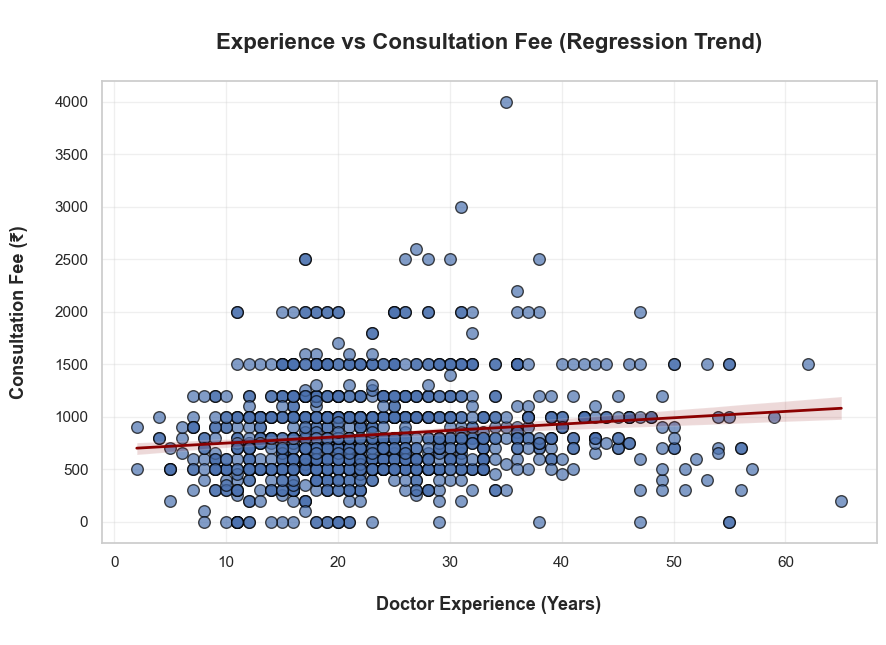

In [41]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))


# Creating a regression plot to analyze the relationship
# between doctor experience and consultation fee
sns.regplot(
    data=df,
    x="Experience",
    y="Consultation_Fee(₹)",
    
    # Customize the scatter points
    scatter_kws={
        "alpha":0.7,        # Slight transparency to reduce overlap
        "s":70,             # Marker size
        "color":"#4C72B0",  # Professional blue color
        "edgecolor":"black" # Black border around points
    },
    
    # Customize the regression trend line
    line_kws={
        "color":"darkred",  # Trend line color
        "linewidth":2       # Thickness of the regression line
    }
)

plt.title("\nExperience vs Consultation Fee (Regression Trend)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nDoctor Experience (Years)\n", fontsize=13, fontweight="bold")
plt.ylabel("Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()


**Key Insights:** Experience vs Consultation Fee
```text
1. Experience Has a Weak Positive Influence on Pricing
 - Suggesting that experience only has a limited influence on pricing.

2️. Large Fee Variation Exists at Similar Experience Levels
 - The scatter points show that doctors with similar years of experience charge very different consultation fees.
   For example,
     doctors with around 15–20 years of experience charge anywhere from ₹300 to ₹1500+.
     This indicates that experience alone does not determine pricing.

3️. Presence of Premium Outliers
 - Even if you see in this plot, Some doctors charge very high consultation fees (₹2500–₹4000) despite having experience levels
   similar to others who charge much less.
   
4️. Mid-Experience Doctors Form the Largest Segment
 - Most doctors in the dataset fall within the 10–30 years of experience range, and their consultation fees mostly
   lie between ₹400 and ₹1000.
   This suggests that the majority of the healthcare market operates in a mid-range pricing segment.

5️. Pricing Is Not Purely Experience-Based
 - Although experience shows a slight positive relationship with consultation fees, the wide spread of data points indicates that
   other factors such as specialization, city, hospital reputation, and market demand play a larger role in determining pricing.
```

### ***2. `Patient Rating Vs Consultation Fee`:***

**A) Correlation (Pearson) Patient Rating and Consultation Fee**

In [42]:
print(df[["Patient_Rating(%)","Consultation_Fee(₹)"]].corr())

corr_value02 = df["Patient_Rating(%)"].corr(df["Consultation_Fee(₹)"])
print(f"\nPearson Correlation between Patient Rating and Consultation Fee: {corr_value02:.3f}\n")

                     Patient_Rating(%)  Consultation_Fee(₹)
Patient_Rating(%)             1.000000            -0.132977
Consultation_Fee(₹)          -0.132977             1.000000

Pearson Correlation between Patient Rating and Consultation Fee: -0.133



**B) Visualization: **Scatter Plot with Regression Line****

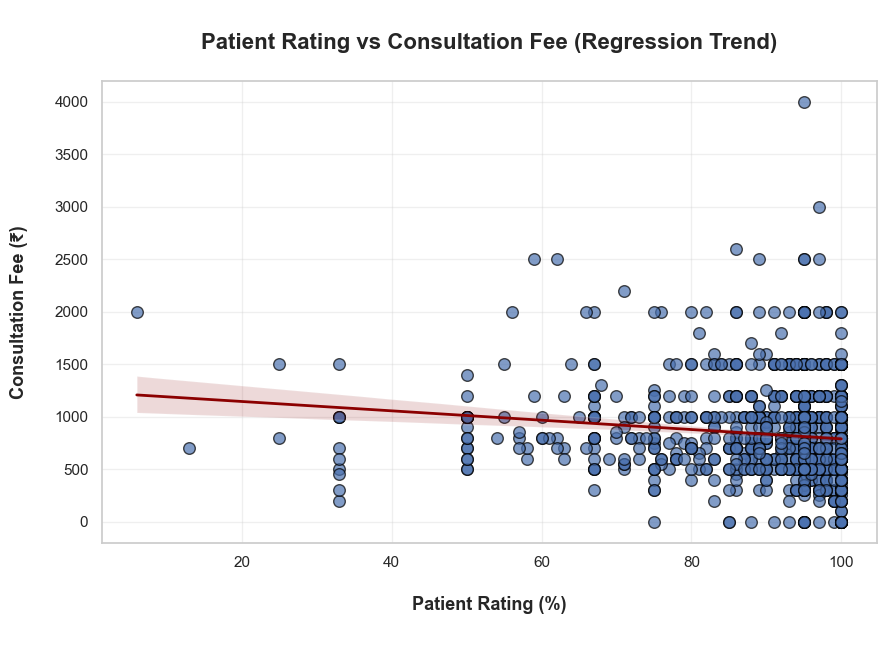

In [43]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Patient_Rating(%)",
    y="Consultation_Fee(₹)",
    
    # Customize the scatter points
    scatter_kws={
        "alpha":0.7,        # Slight transparency to reduce overlap
        "s":70,             # Marker size
        "color":"#4C72B0",  # Professional blue color
        "edgecolor":"black" # Black border around points
    },
    
    # Customize the regression trend line
    line_kws={
        "color":"darkred",  # Trend line color
        "linewidth":2       # Thickness of the regression line
    }
)

plt.title("\nPatient Rating vs Consultation Fee (Regression Trend)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nPatient Rating (%)\n", fontsize=13, fontweight="bold")
plt.ylabel("Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()


**Key Insights:** Patient Rating vs Consultation Fee
```text
1. Doctor Reputation Has Minimal Impact on Pricing
 - The correlation between patient rating and consultation fee is -0.13, indicating a very weak negative relationship.
   This suggests that doctors with higher patient ratings do not necessarily charge higher consultation fees.

2. Higher Ratings Do Not Guarantee Higher Fees
 - The scatter plot shows that doctors with very high ratings (90–100%) charge a wide range of consultation fees,
   from low-cost consultations to premium pricing. This indicates that patient satisfaction does not strongly translate into higher
   consultation pricing.

3. Pricing Variation Exists Across All Rating Levels
 - Across all rating levels, consultation fees vary significantly. Even doctors with similar ratings charge very different fees,
   suggesting that pricing decisions depend on multiple external factors rather than reputation alone.

4️. Slight Negative Trend Indicates Ratings Are Not a Pricing Driver
 - The regression line shows a slightly downward trend, meaning higher-rated doctors sometimes charge even lower fees.
   This further confirms that patient reputation is not a strong pricing driver in this dataset.
```

**C) Group Doctors by Rating Level**

- High Rating vs Low Rating groups:
```text
Rule:
     High Rated Doctors -> Rating ≥ 90
     Low Rated Doctors -> Rating < 90

Note:
    Going with outlier free data points --> `df_no_outliers`
```

In [44]:
df_no_outliers["Rating_Group"] = df_no_outliers["Patient_Rating(%)"].apply(
    lambda x: "High Rated" if x >= 90 else "Lower Rated"
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_40268\579264416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers["Rating_Group"] = df_no_outliers["Patient_Rating(%)"].apply(


In [45]:
df_no_outliers["Rating_Group"].value_counts()

Rating_Group
High Rated     765
Lower Rated    276
Name: count, dtype: int64

**D) Group Doctors by Rating Level and [Avg_Fee, Median_Fee, Number of Doctors]**

In [46]:
rating_fee = df_no_outliers.groupby("Rating_Group")["Consultation_Fee(₹)"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Doctors="count"
).round(2)

rating_fee

,Average_Fee,Median_Fee,Doctors
Rating_Group,,,
High Rated,753.27,700.0,765
Lower Rated,852.36,800.0,276


- **Visualization: Average Consultation Fee by Doctor Rating Group**:

C:\Users\ahmad\AppData\Local\Temp\ipykernel_40268\1609172287.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ahmad\AppData\Local\Temp\ipykernel_40268\1609172287.py:4: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(


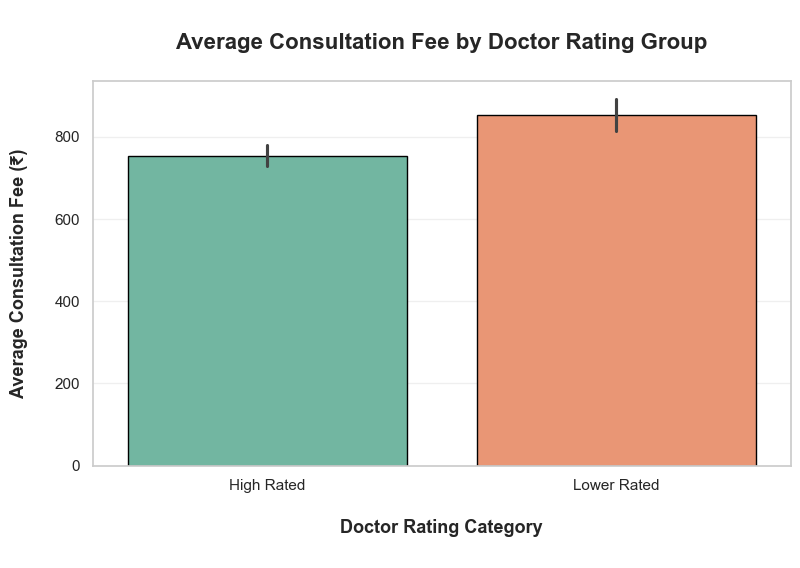

In [47]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))

sns.barplot(
    x="Rating_Group",
    y="Consultation_Fee(₹)",
    data=df_no_outliers,
    palette=sns.color_palette("Set2"),
    edgecolor="black"
)

plt.title("\nAverage Consultation Fee by Doctor Rating Group\n", fontsize=16, fontweight="bold")
plt.xlabel("\nDoctor Rating Category\n", fontsize=13, fontweight="bold")
plt.ylabel("Average Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.show()

### ***2. Correlation Between Key Variables: `Exprience, Patient Rating(%) and Consultation Fee`:***

**A) Visualization: HEATMAP**

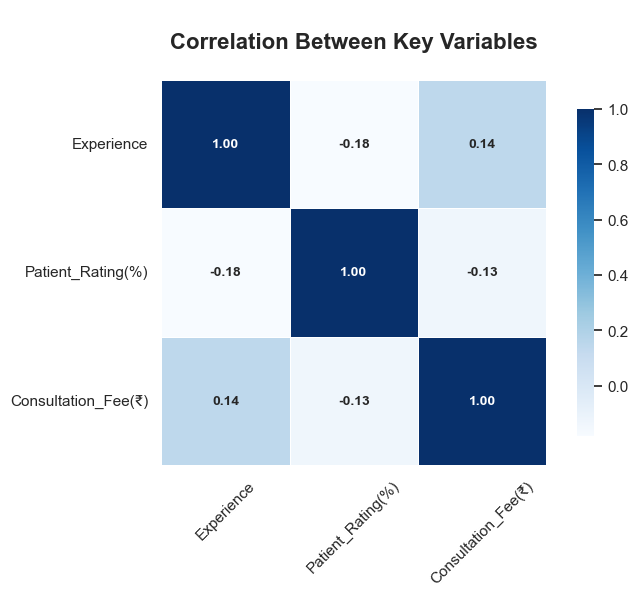

In [48]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

# Creating a correlation heatmap to visualize relationships between variables
sns.heatmap(
    
    # Computing correlation matrix for selected numerical columns
    df[["Experience","Patient_Rating(%)","Consultation_Fee(₹)"]].corr(),
    
    # Display correlation values inside each cell
    annot=True,
    
    # Format correlation values to two decimal places
    fmt=".2f",
    
    # Use a diverging color palette to show positive vs negative correlation
    cmap="Blues",
    
    # Added borders between cells for better clarity
    linewidths=0.5,
    linecolor="white",
    
    # Make cells square-shaped for better visual symmetry
    square=True,
    
    # Added a color bar to indicate correlation scale
    cbar_kws={"shrink":0.85},
    annot_kws={"size":10, "weight":"bold"}
)

plt.title("\nCorrelation Between Key Variables\n", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


**B) In Tabular Form:**

In [49]:
corr_table = df[["Experience", "Patient_Rating(%)", "Consultation_Fee(₹)"]].corr()

corr_table

,Experience,Patient_Rating(%),Consultation_Fee(₹)
Experience,1.000000,-0.182396,0.142079
Patient_Rating(%),-0.182396,1.000000,-0.132977
Consultation_Fee(₹),0.142079,-0.132977,1.000000


**HeatMap Analysis**

When combining this analysis with the correlation heatmap, we observe that: <br>
`Experience vs Fee correlation` = 0.14 (very weak) <br>
`Rating vs Fee correlation` = -0.13 (very weak) <br><br>
This indicates that consultation pricing is not strongly determined by doctor experience or patient ratings.

------------------------

------------------------

**<h1 align="center"><u>PHASE-03</u>: MULTI-FACTOR COMPARATIVE ANALYSIS</h1>**

### **POINT OF DISCUSSION & ANALYSIS:**
1. **`City & Specialization-wise Pricing Analysis`**
2. **`Premium Segment Pricing Analysis`**

### ***1. `CITY & SPECIALIZATION-WISE PRICING ANALYSIS`***

**A) PIVOT TABLE: CITY (vs) SPECIALIZATION**

In [50]:
pivot_city_spec = pd.pivot_table(
    df_no_outliers,
    values="Consultation_Fee(₹)",
    index="City",
    columns="Specialization",
    aggfunc="mean"
).round(0)

pivot_city_spec

Specialization,Cardiologist,Dentist,Dermatologist,ENT,General Physician,General Surgeon,Gynecologist,Neurologist,Orthopedist
City,,,,,,,,,
Ahmedabad,1289.0,370.0,785.0,585.0,880.0,990.0,730.0,930.0,750.0
Bangalore,1080.0,440.0,835.0,890.0,925.0,905.0,655.0,1120.0,820.0
Chandigarh,920.0,490.0,690.0,680.0,560.0,478.0,900.0,688.0,645.0
Chennai,860.0,315.0,870.0,740.0,815.0,835.0,540.0,870.0,605.0
Delhi,1120.0,560.0,1167.0,1056.0,1070.0,900.0,1070.0,1156.0,1050.0
Hyderabad,825.0,380.0,785.0,820.0,705.0,655.0,660.0,810.0,705.0
Kolkata,1033.0,680.0,930.0,1100.0,800.0,1211.0,1030.0,1022.0,935.0
Lucknow,740.0,440.0,520.0,530.0,730.0,520.0,640.0,840.0,715.0
Mumbai,1375.0,500.0,1350.0,1212.0,1240.0,1100.0,1290.0,1500.0,1567.0


- VISUALIZATION - **`HEATMAP`**

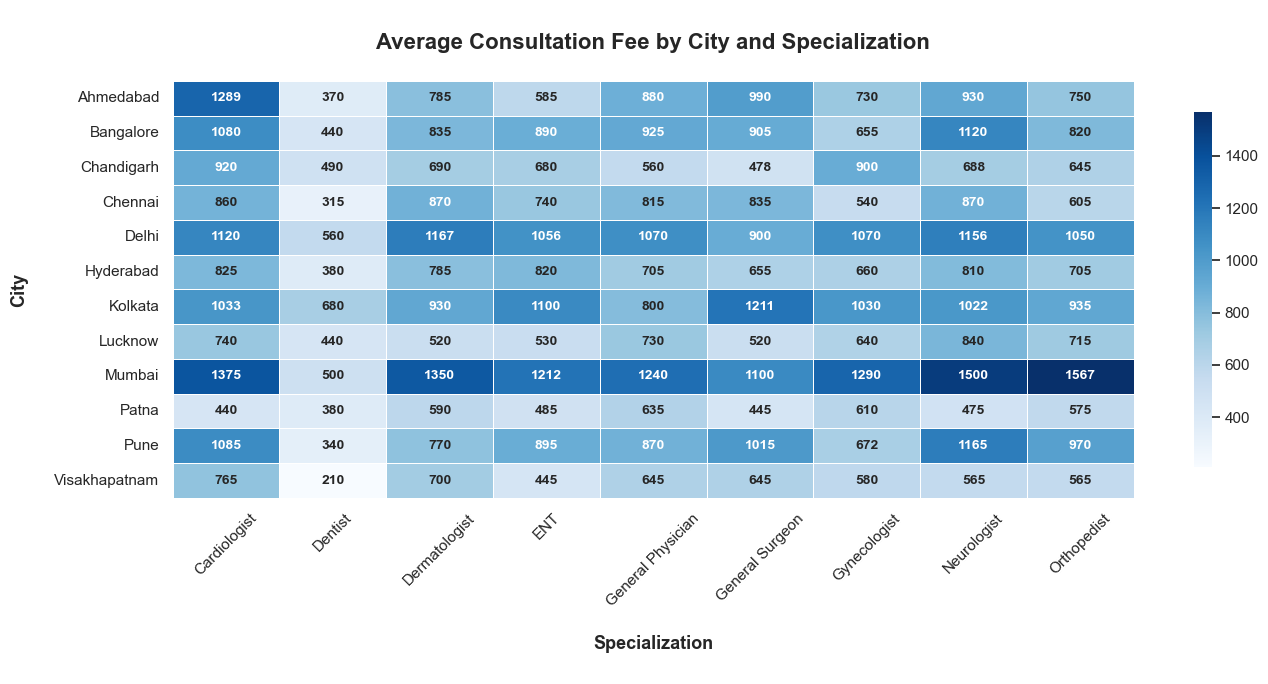

In [51]:
sns.set_theme(style="white")
plt.figure(figsize=(14,7))
ax = sns.heatmap(
    pivot_city_spec,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    square=False,
    cbar_kws={"shrink":0.85},
    annot_kws={"size":10, "weight":"bold"}
)

plt.title("\nAverage Consultation Fee by City and Specialization\n", fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("City\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


```text
Darker colors = higher consultation fees
Lighter colors = lower consultation fees
```
You can instantly identify premium healthcare zones.

- **Key Insights: City × Specialization Pricing**

```text
1. Mumbai emerges as the most expensive healthcare market, with the highest consultation fees across several specializations.
2. Delhi and Kolkata also show relatively high consultation pricing, indicating strong premium healthcare markets.
3. Cities like Patna, Lucknow, and Visakhapatnam offer comparatively affordable healthcare services.
4. Cardiology and Neurology appear as premium medical specializations across many cities.
5. Dentistry remains the most affordable specialization across nearly all cities.
6. Significant regional price differences exist for the same specialization, highlighting strong city-level market effects.
```

- **SPECIFIC COMPARISON**:

##### **i) `Cardiologist Hyderabad vs Delhi`**

In [52]:
pivot_city_spec.loc[["Hyderabad","Delhi"],"Cardiologist"]

City
Hyderabad     825.0
Delhi        1120.0
Name: Cardiologist, dtype: float64

*This allows direct comparison between cities.*

##### **ii) Identify Most Expensive City–Specialization Pair:**

In [53]:
pivot_city_spec.stack().idxmax()

('Mumbai', 'Orthopedist')

##### **iii) Identify Most Affordable Pair**

In [54]:
pivot_city_spec.stack().idxmin()

('Visakhapatnam', 'Dentist')

- **Additional Insight Table**

In [55]:
pivot_city_spec.mean(axis=1).sort_values(ascending=False)

City
Mumbai           1237.111111
Delhi            1016.555556
Kolkata           971.222222
Pune              864.666667
Bangalore         852.222222
Ahmedabad         812.111111
Chennai           716.666667
Hyderabad         705.000000
Chandigarh        672.333333
Lucknow           630.555556
Visakhapatnam     568.888889
Patna             515.000000
dtype: float64

*This ranks cities by overall healthcare pricing level.*

**<h1 align="center"><u>INSIGHTS</u> / <u>ANALYSIS</u></h1>**

```text
1. Significant Pricing Variation Across Cities
 - The heatmap shows that the same medical specialization charges different consultation fees in different cities,
   indicating strong regional pricing differences in urban healthcare markets.

2. Certain Cities Act as Premium Healthcare Markets
 - Some cities like Mumbai, Delhi, and Kolkata consistently display higher consultation fees across multiple specializations,
   suggesting the presence of premium healthcare ecosystems.

3. Specialization Pricing Is Not Uniform Nationwide
 - For the same specialization (e.g., Cardiologist), consultation fees vary across cities, highlighting that local market conditions
   influence healthcare pricing.

4. Premium Healthcare Clusters Exist
 - The heatmap visually reveals clusters where specific city–specialization combinations command significantly higher fees,
   indicating localized demand for specialized healthcare services.
```

### ***`2. PREMIUM SEGMENT PRICING ANALYSIS`***

In [56]:
premium_threshold = df["Consultation_Fee(₹)"].quantile(0.75)
premium_threshold

np.float64(1000.0)

In [57]:
premium_doctors = df[df["Consultation_Fee(₹)"] >= premium_threshold]

premium_doctors.head()

,Doctor_Name,Specialization,Experience,Hospital_Name,City,City_Tier,Patient_Rating(%),Source,Consultation_Fee(₹)
11,Dr. Hema Malathi Rath,Cardiologist,25,Techno India Dama Healthcare & Medical Centre,Kolkata,Metro,95.0,Practo,1200
12,Dr. Ashraful Haque,Cardiologist,20,Techno India Dama Healthcare & Medical Centre,Kolkata,Metro,95.0,Practo,1000
13,Dr. Pradip Saha,Cardiologist,23,Baine Hospital,Kolkata,Metro,95.0,Practo,1000
15,Dr. Subhasish Deb,Cardiologist,13,Techno India Dama Healthcare & Medical Centre,Kolkata,Metro,95.0,Practo,1000
16,Dr. Supratip Kundu,Cardiologist,17,Techno India Dama Healthcare & Medical Centre,Kolkata,Metro,89.0,Practo,2500


- **Number of doctors belong to premium segment**

In [74]:
premium_doctors.shape

(365, 9)

**A) Premium Segment Doctors by City**

In [75]:
premium_city = premium_doctors["City"].value_counts()

premium_city

City
Mumbai           78
Delhi            60
Kolkata          45
Ahmedabad        38
Bangalore        37
Pune             35
Chennai          21
Chandigarh       21
Hyderabad        13
Lucknow          11
Patna             5
Visakhapatnam     1
Name: count, dtype: int64

- **VISUALIZATION: Number of Premium Doctors (vs) City**

C:\Users\ahmad\AppData\Local\Temp\ipykernel_40268\3012089312.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


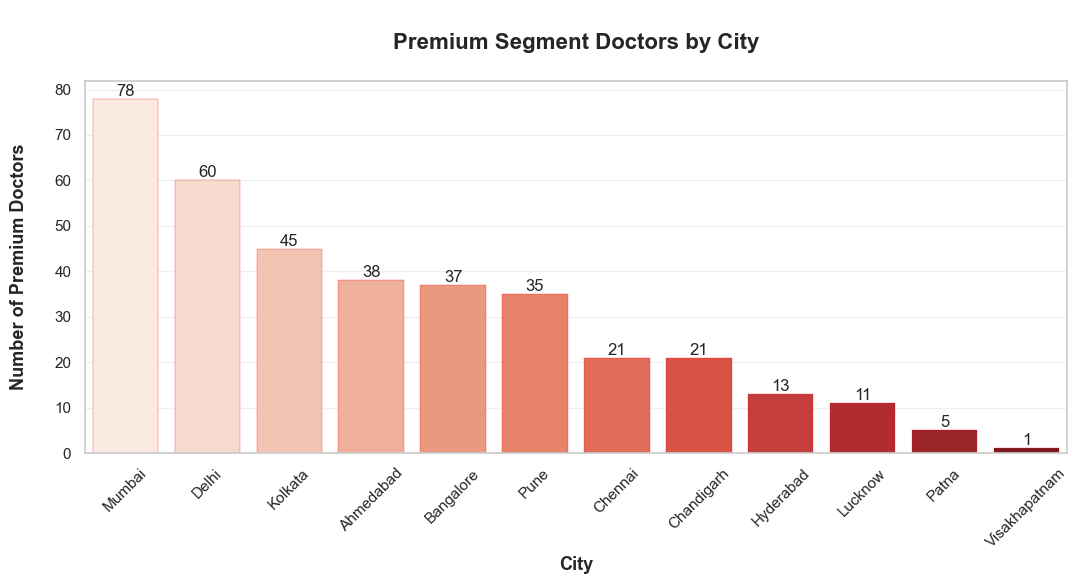

In [60]:
# Visualidation

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11,6))
palette = sns.color_palette("Reds", n_colors=premium_doctors["City"].nunique())
ax = sns.countplot(
    data=premium_doctors,
    x="City",
    order=premium_doctors["City"].value_counts().index,
    palette=palette,
    edgecolor="Red",
    linewidth=0.2
)

plt.title("\nPremium Segment Doctors by City\n", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13, fontweight="bold")
plt.ylabel("Number of Premium Doctors\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

- **VISUALIZATION: Number of Premium Doctors (vs) Specialization**

In [61]:
# Specialization which Dominates Premium Segment

premium_specialization = premium_doctors["Specialization"].value_counts()

premium_specialization

Specialization
Neurologist          64
Cardiologist         60
General Physician    43
General Surgeon      43
ENT                  40
Gynecologist         38
Dermatologist        37
Orthopedist          36
Dentist               4
Name: count, dtype: int64

C:\Users\ahmad\AppData\Local\Temp\ipykernel_40268\279109624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


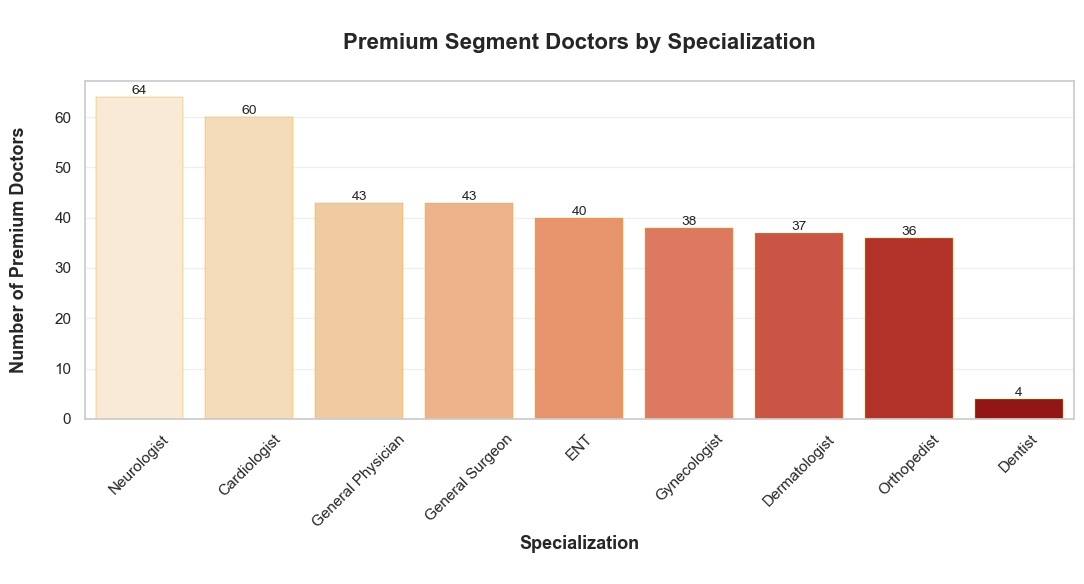

In [62]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11,6))
# palette = sns.color_palette("Greens", n_colors=premium_doctors["Specialization"].nunique())
ax = sns.countplot(
    data=premium_doctors,
    x="Specialization",
    order=premium_doctors["Specialization"].value_counts().index,
    palette="OrRd",
    edgecolor="Orange",
    linewidth=0.3
)

plt.title("\nPremium Segment Doctors by Specialization\n", fontsize=16, fontweight="bold")
plt.xlabel("Specialization\n", fontsize=13, fontweight="bold")
plt.ylabel("Number of Premium Doctors\n", fontsize=13, fontweight="bold")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

**B) City × Specialization Premium Heatmap**

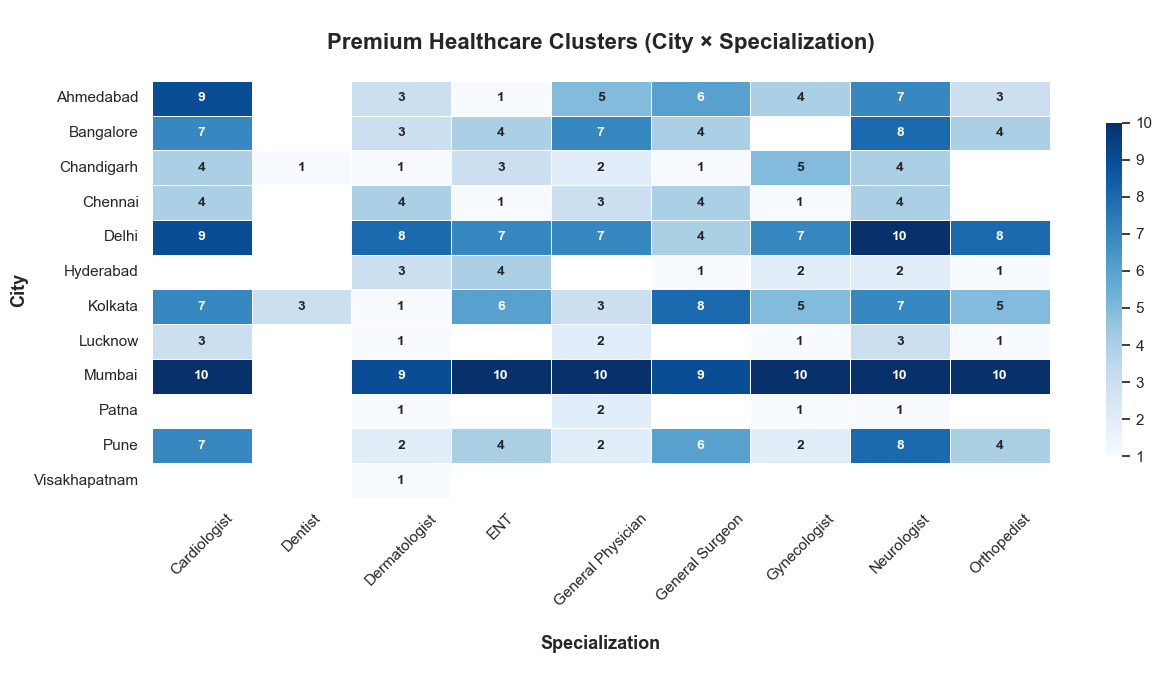

In [63]:
sns.set_theme(style="white")
premium_pivot = pd.pivot_table(
    premium_doctors,
    values="Consultation_Fee(₹)",
    index="City",
    columns="Specialization",
    aggfunc="count"
)

plt.figure(figsize=(13,7))

ax = sns.heatmap(
    premium_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink":0.8},
    annot_kws={"size":10,"weight":"bold"}
)

plt.title("\nPremium Healthcare Clusters (City × Specialization)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("City", fontsize=13, fontweight="bold")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**<h1 align="center"><u>INSIGHTS</u> / <u>ANALYSIS</u></h1>**

**Insight-01 — Premium Healthcare Market Concentration**
```text
The premium segment (top 25% consultation fees) represents doctors charging significantly above the typical market price, indicating a specialized high-value healthcare segment.
```

**Insight-02 — Premium Doctors Are Concentrated in Major Cities**
```text
Analysis shows that premium consultation providers are largely concentrated in major metropolitan cities like Mumbai, Delhi and Kolkata, suggesting stronger demand for high-end healthcare services.
```

**Insight-03 — Certain Specializations Dominate the Premium Segment**
```text
Specializations such as Cardiology, Neurology, and General Physicians appear more frequently in the premium segment, indicating that highly specialized medical services tend to command higher consultation fees.
```

**Insight-04 — Urban Premium Healthcare Clusters Exist**
```text
The distribution of premium doctors across cities and specializations reveals clear urban healthcare clusters, where certain cities and specialties dominate the high-fee segment.
```

------------

------------

**<h1 align="center"><u>PHASE-04</u>: MARKET SEGMENT</h1>**

### **POINT OF DISCUSSION & ANALYSIS:**
1. **`Market Segment Pricing Analysis`**

### ***1. `MARKET SEGMENTATION PRICING ANALYSIS`***

- **Fee-Range**
```text
Budget --> Bottom 33%
Mid-range --> Middle 33%
Premium --> Top 33%
```

In [64]:
df["Fee_Segment"] = pd.qcut(
    df["Consultation_Fee(₹)"],
    q=3,
    labels=["Budget", "Mid-range", "Premium"]
)

df.head()

,Doctor_Name,Specialization,Experience,Hospital_Name,City,City_Tier,Patient_Rating(%),Source,Consultation_Fee(₹),Fee_Segment
0,Dr. Anil Krishna Gundala,Cardiologist,23,Medicover Hospitals,Hyderabad,Metro,96.0,Practo,800,Mid-range
1,Dr. Sai Ravi Shanker A,Cardiologist,31,Aster Prime Hospital,Hyderabad,Metro,60.0,Practo,800,Mid-range
2,Dr. R. Balaji,Cardiologist,37,Medicover Hospitals,Hyderabad,Metro,97.0,Practo,900,Mid-range
3,Dr. Krishna Prasad A R,Cardiologist,32,Medicover Hospitals,Hyderabad,Metro,82.0,Practo,800,Mid-range
4,Dr. Shiva Prasad Koyalakonda,Cardiologist,23,One Cardiac Centre,Hyderabad,Metro,93.0,Practo,700,Mid-range


`pd.qcut()`

```text
This is a Pandas function used for quantile-based binning.

Meaning:
- It divides data into equal-sized groups based on ranking.
- For example:
    If you have 100 values and choose q=4, then:

                | Quantile | Data Portion |
                | -------- | ------------ |
                | Q1       | 25 values    |
                | Q2       | 25 values    |
                | Q3       | 25 values    |
                | Q4       | 25 values    |

    So every group has equal number of observations.
    And in this case we have choosen q = 3,
     that means data divided in 33 value in each 3 quantile

```
By default, `pd.qcut()` **labels** are assigned from the lowest values to the highest values.                

**A) Check Overall Market Structure**

In [76]:
df["Fee_Segment"].value_counts()

Fee_Segment
Mid-range    467
Budget       393
Premium      220
Name: count, dtype: int64

- **Segment Distribution by City**

In [77]:
city_segment = pd.crosstab(df["City"], df["Fee_Segment"])
city_segment

Fee_Segment,Budget,Mid-range,Premium
City,,,
Ahmedabad,34,37,19
Bangalore,26,41,23
Chandigarh,36,45,9
Chennai,38,45,7
Delhi,11,48,31
Hyderabad,35,53,2
Kolkata,17,36,37
Lucknow,42,46,2
Mumbai,11,15,64


- **VISUALIZATION: Consultation Fee Segments by City**

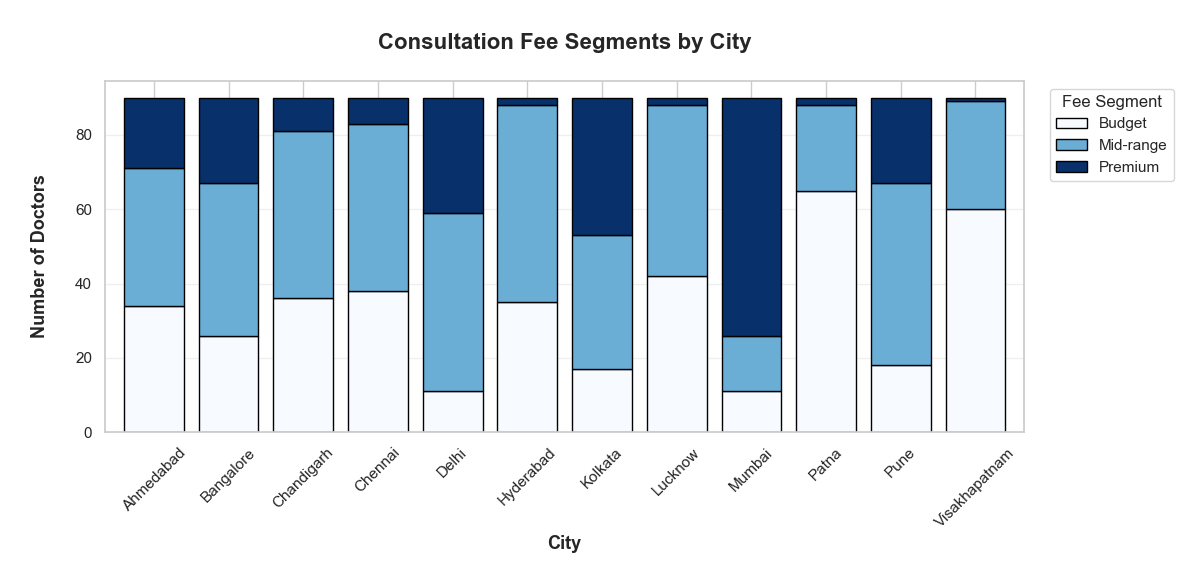

In [67]:
sns.set_theme(style="whitegrid")
ax = city_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Blues",
    edgecolor="black",
    width=0.8
)

plt.title("\nConsultation Fee Segments by City\n", fontsize=16, fontweight="bold")
plt.xlabel("City\n", fontsize=13, fontweight="bold")
plt.ylabel("\nNumber of Doctors\n", fontsize=13, fontweight="bold")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    title="Fee Segment",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**B) Segment Distribution by Specialization**

In [78]:
spec_segment = pd.crosstab(df["Specialization"], df["Fee_Segment"])
spec_segment

Fee_Segment,Budget,Mid-range,Premium
Specialization,,,
Cardiologist,14,67,39
Dentist,111,7,2
Dermatologist,34,65,21
ENT,45,53,22
General Physician,35,63,22
General Surgeon,40,53,27
Gynecologist,46,56,18
Neurologist,26,50,44
Orthopedist,42,53,25


- **Visualization : Consultation Fee segment by Specialization**

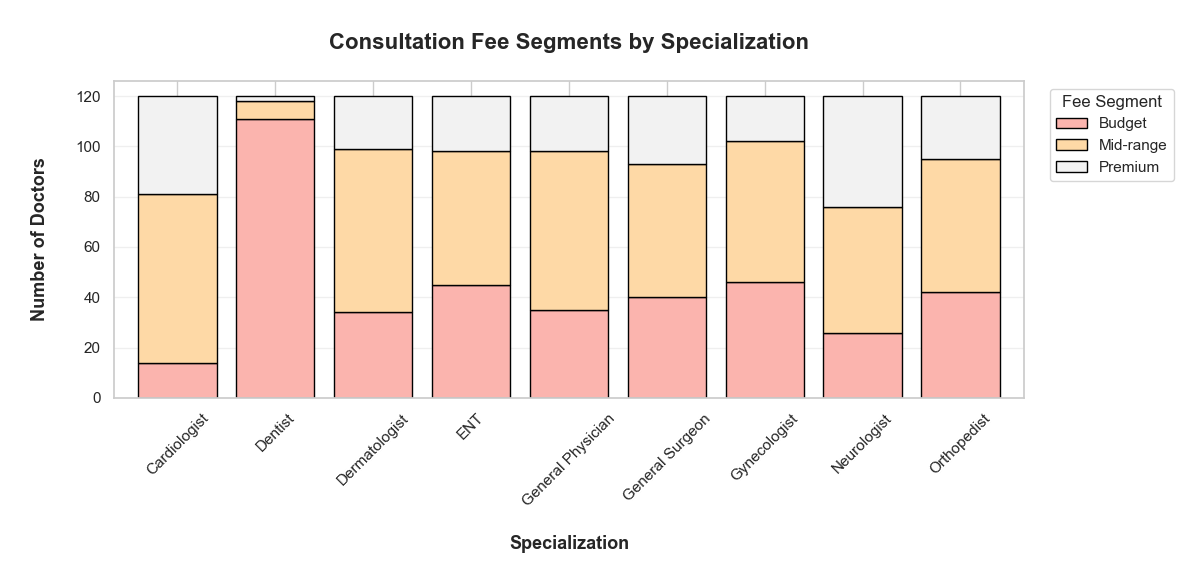

In [69]:
sns.set_theme(style="whitegrid")
ax = spec_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Pastel1",
    edgecolor="black",
    width=0.8
)

plt.title("\nConsultation Fee Segments by Specialization\n", fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("\nNumber of Doctors\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    title="Fee Segment",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

*This reveals which medical domains dominate premium healthcare.*

In [70]:
# Premium Share by City (Advanced Insight)

premium_share_city = city_segment.div(city_segment.sum(axis=1), axis=0)
premium_share_city


Fee_Segment,Budget,Mid-range,Premium
City,,,
Ahmedabad,0.377778,0.411111,0.211111
Bangalore,0.288889,0.455556,0.255556
Chandigarh,0.400000,0.500000,0.100000
Chennai,0.422222,0.500000,0.077778
Delhi,0.122222,0.533333,0.344444
Hyderabad,0.388889,0.588889,0.022222
Kolkata,0.188889,0.400000,0.411111
Lucknow,0.466667,0.511111,0.022222
Mumbai,0.122222,0.166667,0.711111


*This shows the percentage of premium doctors in each city.*

In [71]:
# Premium Share by Specialization

premium_share_spec = spec_segment.div(spec_segment.sum(axis=1), axis=0)
premium_share_spec

Fee_Segment,Budget,Mid-range,Premium
Specialization,,,
Cardiologist,0.116667,0.558333,0.325000
Dentist,0.925000,0.058333,0.016667
Dermatologist,0.283333,0.541667,0.175000
ENT,0.375000,0.441667,0.183333
General Physician,0.291667,0.525000,0.183333
General Surgeon,0.333333,0.441667,0.225000
Gynecologist,0.383333,0.466667,0.150000
Neurologist,0.216667,0.416667,0.366667
Orthopedist,0.350000,0.441667,0.208333


*This identifies which specialties dominate the premium segment.*

**<h1 align="center"><u>INSIGHTS</u> / <u>ANALYSIS</u></h1>**

**Insight-01 — Healthcare Market Shows Clear Price Segmentation**
```text
The consultation fee distribution reveals a clear segmentation into budget, mid-range, and premium healthcare providers, indicating a structured pricing hierarchy within urban healthcare markets.
```

**Insight-02 — Premium Healthcare Providers Are Concentrated in Certain Cities**
```text
Major metropolitan cities tend to have a higher proportion of doctors in the premium segment, reflecting stronger demand for specialized and high-quality healthcare services.
```

**Insight-03 — Certain Specializations Dominate Premium Healthcare**
```text
Highly specialized medical fields such as Cardiology, Neurology, and General Physician are more likely to fall within the premium pricing segment.
```

**Insight-04 — Budget Healthcare Is More Common in Emerging Cities**
```text
Smaller or emerging cities like Pune, Patna and Visakhapatnam tend to have a higher proportion of budget and mid-range healthcare providers, indicating more accessible consultation pricing.
```

------------

------------

$$
\text{Thank You}
$$
$$
\text{Afroz Shams}
$$